# Functions

A list of instruction of how each function is configured is displayed here:

visualize_pure_cca_mode(X, y, N_PC_COMPONENTS = 5 ): : Left / Right CCA Visualization

run_top_bottom_experiment(X_global, y_global, n_components=5) : Top/Bottom CCA Visualization

def display_top_bottom_split(X, y, defined_number_visual_split) : Show Top / Bottom Split picture

visualize_pc_matrix_digit_1(X_global, y_global): Visualizing A Given Number's Left/Right PCs

inspect_cca_weights(X_global, y_global, target_digit=8, n_components=5): Inspecting Up/Down Weight Of CCA in Table and Bar Plot

def inspect_cca_weights_lr(X, y, target_digit=1, n_components=5): Inspecting Left/Right Weight Of CCA in Table and Bar Plot

visualize_digit_5_pc1_only(X_global, y_global): Visualizing 5's PC1

inspect_cca_7weights(X_global, y_global, target_digit=7, n_components=5): Inspecting weight of CCA and its PCA's visualization of 7.

verify_variance_coverage(X_global, y_global, n_components=20): Display variance explained

run_mnist_cca_analysis(file_path="mnist.csv", sample_size=5000, n_pca=5): Display Correlation Chart

Display_Number(user_defined_num = 0): Display 10 random sample of a given number

run_mnist_spatial_analysis("mnist.csv", n_components=20): Display Scree Plot of Top 20 Variance

run_hd_reconstruction_demo(X_global,y_global): Perform Linear Regression to Restore Number Structure

# Codes

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os

# Global Environment Configurations
DATA_PATH = "mnist.csv"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

if not os.path.exists("plots"):
    os.makedirs("plots")

# print("Libraries imported and configuration set.")

def load_data_global(path, sample_size=None):
    """
    Load data and apply pre-processing
    """
    print(f"Loading data from {path}...")
    if not os.path.exists(path):
        print("Error: File not found. Please check DATA_PATH.")
        return None, None

    df = pd.read_csv(path)

    # Sample Size Adjustments
    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)
        print(f"Data sampled to {sample_size} rows.")

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    print(f"Data Loaded Successfully. Shape: {X.shape}")
    return X, y

X_global, y_global = load_data_global(DATA_PATH, sample_size=5000)

def visualize_pure_cca_mode(X, y,N_PC_COMPONENTS ):

    print(f"\n--- Running Pure CCA Analysis (PC Count = {N_PC_COMPONENTS}) ---")

    IMG_SIZE = 28
    CUT_COL = 14 # 图像左右分割线

    # 设置布局：2行5列 (0-4 第一行, 5-9 第二行)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten() # 展平方便索引 0-9

    # 颜色映射 (红=正相关, 蓝=负相关, 白=无相关)
    cmap = 'seismic'

    for digit in range(10):
        print(f"Processing Digit {digit}...", end="\r")
        ax = axes[digit]

        # --- 1. 数据清洗 (Clean Norm) ---
        X_digit = X[y == digit]
        # 仅除以 255，不减均值不除方差，保持背景纯净
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # --- 2. 左右切分 ---
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
        X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)
        X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)

        # --- 3. PCA 降维 (Denoising) ---
        # 使用上面定义的 N_PC_COMPONENTS
        pca_l = PCA(n_components=N_PC_COMPONENTS, random_state=42)
        pca_r = PCA(n_components=N_PC_COMPONENTS, random_state=42)

        X_l_pca = pca_l.fit_transform(X_left)
        X_r_pca = pca_r.fit_transform(X_right)

        # --- 4. CCA 关联分析 ---
        cca = CCA(n_components=1)
        cca_img = np.zeros((28, 28))
        corr = 0

        try:
            cca.fit(X_l_pca, X_r_pca)

            # 计算相关系数 rho
            U, V = cca.transform(X_l_pca, X_r_pca)
            corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

            # 逆向投影权重 (Back-projection)
            w_l = cca.x_weights_[:, 0]
            w_r = cca.y_weights_[:, 0]

            # 权重映射回像素空间
            # pattern = Weight * Components
            pattern_l = np.dot(w_l, pca_l.components_).reshape(28, CUT_COL)
            pattern_r = np.dot(w_r, pca_r.components_).reshape(28, CUT_COL)

            # 拼接
            cca_img[:, :CUT_COL] = pattern_l
            cca_img[:, CUT_COL:] = pattern_r

        except Exception as e:
            print(f"Error on {digit}: {e}")

        # --- 5. 绘图 ---
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1

        im = ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')

        # 标题：数字 + 相关系数
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')

        # 在图下方简单标注当前使用的 PC 数量
        ax.text(0.5, -0.1, f"PCs used: {N_PC_COMPONENTS}",
                transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    plt.suptitle(f"CCA Geometry Analysis: Left-Right Correlation Patterns (Based on Top {N_PC_COMPONENTS} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

def verify_variance_coverage(X, y, n_components=15):
    print(f"--- Evidence Verification: Cumulative Variance for Top {n_components} PCs ---")

    # 准备存储结果的列表
    data = []

    IMG_SIZE = 28
    CUT_COL = 14

    # 遍历 0 到 9
    for digit in range(10):
        # 1. 提取当前数字的数据
        X_digit = X[y == digit]

        # 2. 归一化 (Clean Norm)
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # 3. 切分左右
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
        X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)  # Flatten
        X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)  # Flatten

        # 4. 分别运行 PCA
        # 我们只关心 n_components 能解释多少方差
        pca_l = PCA(n_components=n_components, random_state=42)
        pca_l.fit(X_left)

        pca_r = PCA(n_components=n_components, random_state=42)
        pca_r.fit(X_right)

        # 5. 计算累计解释方差 (Cumulative Variance Explained)
        # explained_variance_ratio_ 是一个数组，包含每个PC解释的比例
        # np.sum 将它们加起来
        total_var_l = np.sum(pca_l.explained_variance_ratio_)
        total_var_r = np.sum(pca_r.explained_variance_ratio_)

        data.append({
            "Digit": digit,
            "Left Variance": f"{total_var_l:.2%}",
            "Right Variance": f"{total_var_r:.2%}",
            # 保存数值以便后续检查平均值
            "L_val": total_var_l,
            "R_val": total_var_r
        })

    # 转换为 DataFrame 展示表格
    df_results = pd.DataFrame(data)

    # 计算所有数字的平均值
    avg_l = df_results["L_val"].mean()
    avg_r = df_results["R_val"].mean()

    # 移除临时的数值列，只保留格式化后的字符串
    display_df = df_results.drop(columns=["L_val", "R_val"])

    print("\nTable: Cumulative Variance Explained (PVE) by Top 20 PCs")
    print(display_df.to_markdown(index=False))  # Markdown格式打印，美观

    print("\n--- Summary Statistics ---")
    print(f"Average Variance Explained (Left):  {avg_l:.2%}")
    print(f"Average Variance Explained (Right): {avg_r:.2%}")

    # 简单的逻辑判断
    threshold = 0.80
    if avg_l > threshold and avg_r > threshold:
        print(
            f"\n[CONCLUSION] Hypothesis Confirmed: Top {n_components} PCs capture >{threshold:.0%} of the information.")
    else:
        print(f"\n[CONCLUSION] Hypothesis Weak: Top {n_components} PCs might not be enough.")

def run_top_bottom_experiment(X, y, n_components=15):
    # ==========================================
    # 参数设置
    # ==========================================
    print(f"\n=== Running Top-Bottom Split Experiment (PCs={n_components}) ===")

    IMG_SIZE = 28
    CUT_ROW = 14  # 水平切割点：0-13行为上部，14-27行为下部

    # 准备存储表格数据
    table_data = []

    # 准备绘图画布 (2行5列)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten()
    cmap = 'seismic'

    # ==========================================
    # 循环处理每个数字 0-9
    # ==========================================
    for digit in range(10):
        print(f"Processing Digit {digit}...", end="\r")

        # --- 1. 数据准备 (Data Prep) ---
        X_digit = X[y == digit]
        # 保持背景纯净的归一化
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # 还原为图像矩阵 (N, 28, 28)
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

        # --- 2. 上下切割 (Top-Bottom Split) ---
        # Top: 取前 14 行 (Row 0-13)，所有列
        X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
        # Bottom: 取后 14 行 (Row 14-27)，所有列
        X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

        # --- 3. PCA 降维 (Independent PCA) ---
        pca_t = PCA(n_components=n_components, random_state=42)
        pca_b = PCA(n_components=n_components, random_state=42)

        X_t_pca = pca_t.fit_transform(X_top)
        X_b_pca = pca_b.fit_transform(X_bottom)

        # --- 4. 收集方差数据 (Variance Table Report) ---
        var_t = np.sum(pca_t.explained_variance_ratio_)
        var_b = np.sum(pca_b.explained_variance_ratio_)

        table_data.append({
            "Digit": digit,
            "Top Variance": f"{var_t:.2%}",
            "Bottom Variance": f"{var_b:.2%}",
            "T_val": var_t, # 用于后续算平均值
            "B_val": var_b
        })

        # --- 5. CCA 关联分析 (Correlation) ---
        cca = CCA(n_components=1)
        cca_img = np.zeros((IMG_SIZE, IMG_SIZE))
        corr = 0

        try:
            cca.fit(X_t_pca, X_b_pca)

            # 计算相关系数 rho
            U, V = cca.transform(X_t_pca, X_b_pca)
            corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

            # 逆向投影 (Back-projection)
            w_t = cca.x_weights_[:, 0]
            w_b = cca.y_weights_[:, 0]

            # 还原形状：Top是 (14, 28), Bottom是 (14, 28)
            pattern_t = np.dot(w_t, pca_t.components_).reshape(CUT_ROW, 28)
            pattern_b = np.dot(w_b, pca_b.components_).reshape(IMG_SIZE - CUT_ROW, 28)

            # 上下拼接
            cca_img[:CUT_ROW, :] = pattern_t
            cca_img[CUT_ROW:, :] = pattern_b

        except Exception as e:
            print(f"CCA Error on {digit}: {e}")

        # --- 6. 绘图 (Plotting) ---
        ax = axes[digit]
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1

        im = ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')

        # 底部标注
        ax.text(0.5, -0.1, f"PCs used: {n_components}",
                transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    # ==========================================
    # 输出报告
    # ==========================================

    # 1. 打印方差表格
    df_res = pd.DataFrame(table_data)
    avg_t = df_res["T_val"].mean()
    avg_b = df_res["B_val"].mean()

    # 整理表格列
    display_df = df_res.drop(columns=["T_val", "B_val"])

    print("\n\nTable: Cumulative Variance Explained (Top vs Bottom Split)")
    print(display_df.to_markdown(index=False))

    print("\n--- Summary Statistics ---")
    print(f"Average Variance Explained (Top):    {avg_t:.2%}")
    print(f"Average Variance Explained (Bottom): {avg_b:.2%}")

    # 2. 显示图像
    plt.suptitle(f"Top-Bottom CCA Geometry: Correlation Patterns (Top {n_components} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

def display_top_bottom_split(X, y, defined_number_visual_split):

    IMG_SIZE = 28
    CUT_ROW = 14  # 水平切割点：0-13行为上部，14-27行为下部

    # ---------------------------------------------------------
    # [SANITY CHECK] 视觉验证切片逻辑
    # ---------------------------------------------------------
    # 取出一个数字 0 的样本来看看
    sample_digit = X[y == defined_number_visual_split][0].reshape(IMG_SIZE, IMG_SIZE) / 255.0

    # 模拟切片
    sample_top = sample_digit[:CUT_ROW, :]
    sample_bottom = sample_digit[CUT_ROW:, :]

    # 绘图验证
    fig_check, ax_check = plt.subplots(1, 3, figsize=(10, 3))
    ax_check[0].imshow(sample_digit, cmap='gray')
    ax_check[0].set_title("Original (Digit 0)")

    ax_check[1].imshow(sample_top, cmap='gray')
    ax_check[1].set_title("Top Slice (Rows 0-13)")

    ax_check[2].imshow(sample_bottom, cmap='gray')
    ax_check[2].set_title("Bottom Slice (Rows 14-27)")

    plt.suptitle(" ", fontsize=14, color='red')
    plt.show()
    # ---------------------------------------------------------

def visualize_pc_matrix_digit_1(X, y):
    print("\n=== Generating PC1-PC5 Matrix for Digit '1' (4-Way Split) ===")

    # 1. 准备数据 (Digit 1 Only)
    X_digit = X[y == 1]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    # 还原为图像
    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 2. 准备四份数据 (Four Parts)
    # Top (Row 0-13)
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # Bottom (Row 14-27)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # Left (Col 0-13)
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # Right (Col 14-27)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 3. 训练 4 个独立的 PCA
    # 我们只需要前 5 个 PC
    n_comps = 5
    pca_t = PCA(n_components=n_comps, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_comps, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components=n_comps, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_comps, random_state=42).fit(X_right)

    # 4. 绘图矩阵 (4行 x 5列)
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))

    # 定义每一行的配置
    rows_config = [
        ("Top Split", pca_t, (14, 28)),    # (Title, Model, ReshapeSize)
        ("Bottom Split", pca_b, (14, 28)),
        ("Left Split", pca_l, (28, 14)),
        ("Right Split", pca_r, (28, 14))
    ]

    cmap = 'seismic'

    for row_idx, (title, model, shape) in enumerate(rows_config):
        # 获取该模型的所有 components (shape: 5, n_features)
        components = model.components_

        for col_idx in range(n_comps):
            ax = axes[row_idx, col_idx]

            # 获取第 k 个 PC 并 reshape
            pc_img = components[col_idx].reshape(shape)

            # 为了增强对比度，我们将 vmin/vmax 设为对称
            v_max = np.max(np.abs(pc_img))

            im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])

            # 标签设置
            if row_idx == 0:
                ax.set_title(f"PC {col_idx+1}", fontsize=12, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(title, fontsize=14, fontweight='bold', rotation=90)

    # 添加 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Eigen-value Weight (Red+, Blue-)')

    plt.suptitle("Eigen-Image Matrix for Digit '1': Top/Bottom vs Left/Right (Top 5 PCs)\nEvidence of Translation vs Rotation", fontsize=16, y=0.95)
    plt.subplots_adjust(wspace=0.1, hspace=0.1, right=0.9)
    plt.show()

def inspect_cca_weights(X, y, target_digit=2, n_components=5):
    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Top-Bottom Split) ===")

    # --- 1. 数据准备 ---
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT_ROW = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
    X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

    # --- 2. PCA 降维 ---
    pca_t = PCA(n_components=n_components, random_state=42)
    pca_b = PCA(n_components=n_components, random_state=42)

    X_t_pca = pca_t.fit_transform(X_top)
    X_b_pca = pca_b.fit_transform(X_bottom)

    # --- 3. CCA 核心 ---
    cca = CCA(n_components=1)
    cca.fit(X_t_pca, X_b_pca)

    # [!] 获取权重 [!]
    # x_weights_ 对应 X_top 的权重
    # y_weights_ 对应 X_bottom 的权重
    # shape is (n_features, n_components), we want the first component
    w_top = cca.x_weights_[:, 0]
    w_bottom = cca.y_weights_[:, 0]

    # --- 4. 打印数值表格 ---
    print("\n--- CCA Weight Distribution (The 'Recipe') ---")
    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i+1}" for i in range(n_components)],
        "Top_Weight": w_top,
        "Bottom_Weight": w_bottom,
        "Abs_Top_Strength": np.abs(w_top) # 用于排序或观察绝对强度
    })

    # 打印原始数值
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # 找出那个“捣乱”的主导成分
    dominant_idx = np.argmax(np.abs(w_top))
    print(f"\n[Observation] The dominant component in Top half is PC{dominant_idx+1} (Weight: {w_top[dominant_idx]:.4f})")

    # --- 5. 可视化柱状图 ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 颜色：正值为红，负值为蓝
    colors_top = ['red' if x >= 0 else 'blue' for x in w_top]
    colors_bottom = ['red' if x >= 0 else 'blue' for x in w_bottom]

    x_indices = np.arange(1, n_components + 1)

    # Top Weights
    axes[0].bar(x_indices, w_top, color=colors_top, alpha=0.7)
    axes[0].set_title(f"CCA Weights for Top Half (Digit {target_digit})", fontsize=14)
    axes[0].set_xlabel("Principal Components")
    axes[0].set_ylabel("Weight Value")
    axes[0].set_xticks(x_indices)
    axes[0].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Bottom Weights
    axes[1].bar(x_indices, w_bottom, color=colors_bottom, alpha=0.7)
    axes[1].set_title(f"CCA Weights for Bottom Half (Digit {target_digit})", fontsize=14)
    axes[1].set_xlabel("Principal Components")
    axes[1].set_xticks(x_indices)
    axes[1].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle(f"Which PC dominates the correlation? (k={n_components})", fontsize=16)
    plt.show()

def inspect_cca_weights_lr(X, y, target_digit=1, n_components=5):
    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Left-Right Split) ===")

    # --- 1. 数据准备 ---
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT_COL = 14  # 左右切割点

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # [关键修改] 使用列切片
    # Left:  [:, :, :14]
    # Right: [:, :, 14:]
    X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)
    X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)

    # --- 2. PCA 降维 ---
    pca_l = PCA(n_components=n_components, random_state=42)
    pca_r = PCA(n_components=n_components, random_state=42)

    X_l_pca = pca_l.fit_transform(X_left)
    X_r_pca = pca_r.fit_transform(X_right)

    # --- 3. CCA 核心 ---
    cca = CCA(n_components=1)
    cca.fit(X_l_pca, X_r_pca)

    # [!] 获取权重 [!]
    # x_weights_ 对应 X_left
    # y_weights_ 对应 X_right
    w_left = cca.x_weights_[:, 0]
    w_right = cca.y_weights_[:, 0]

    # --- 4. 打印数值表格 ---
    print("\n--- CCA Weight Distribution (Left-Right Split) ---")
    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i+1}" for i in range(n_components)],
        "Left_Weight": w_left,
        "Right_Weight": w_right,
        "Abs_Left_Strength": np.abs(w_left)
    })

    # 打印原始数值
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # 找出主导成分
    dominant_idx_l = np.argmax(np.abs(w_left))
    dominant_idx_r = np.argmax(np.abs(w_right))
    print(f"\n[Observation] Dominant Left PC: PC{dominant_idx_l+1} (Weight: {w_left[dominant_idx_l]:.4f})")
    print(f"[Observation] Dominant Right PC: PC{dominant_idx_r+1} (Weight: {w_right[dominant_idx_r]:.4f})")

    # --- 5. 可视化柱状图 ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 颜色逻辑：红色为正，蓝色为负
    colors_left = ['red' if x >= 0 else 'blue' for x in w_left]
    colors_right = ['red' if x >= 0 else 'blue' for x in w_right]

    x_indices = np.arange(1, n_components + 1)

    # Left Weights
    axes[0].bar(x_indices, w_left, color=colors_left, alpha=0.7)
    axes[0].set_title(f"CCA Weights for LEFT Half (Digit {target_digit})", fontsize=14)
    axes[0].set_xlabel("Principal Components")
    axes[0].set_ylabel("Weight Value")
    axes[0].set_xticks(x_indices)
    axes[0].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Right Weights
    axes[1].bar(x_indices, w_right, color=colors_right, alpha=0.7)
    axes[1].set_title(f"CCA Weights for RIGHT Half (Digit {target_digit})", fontsize=14)
    axes[1].set_xlabel("Principal Components")
    axes[1].set_xticks(x_indices)
    axes[1].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle(f"Left-Right CCA: Evidence of Competing Geometric Modes (k={n_components})", fontsize=16)
    plt.tight_layout()
    plt.show()

def visualize_digit_5_pc1_only(X, y):
    print("\n=== Extracting PC1 for Digit '5' (All 4 Splits) ===")

    # 1. 数据准备 (Digit 5 Only)
    X_digit = X[y == 5]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    # 还原为图像
    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 2. 准备四份数据
    # Top (Row 0-13)
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # Bottom (Row 14-27)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # Left (Col 0-13)
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # Right (Col 14-27)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 3. 训练 4 个独立的 PCA (只取 PC1)
    pca_t = PCA(n_components=1, random_state=42).fit(X_top)
    pca_b = PCA(n_components=1, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components=1, random_state=42).fit(X_left)
    pca_r = PCA(n_components=1, random_state=42).fit(X_right)

    # 4. 绘图 (1行 4列)
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    # 配置列表
    # (Title, Component, ReshapeSize)
    plots_config = [
        ("Top Split PC1\n(Translation?)", pca_t.components_[0], (14, 28)),
        ("Bottom Split PC1\n(Translation?)", pca_b.components_[0], (14, 28)),
        ("Left Split PC1\n(Shear/Tilt?)", pca_l.components_[0], (28, 14)),
        ("Right Split PC1\n(Shear/Tilt?)", pca_r.components_[0], (28, 14))
    ]

    cmap = 'seismic'

    for ax, (title, component, shape) in zip(axes, plots_config):
        # Reshape
        pc_img = component.reshape(shape)

        # 归一化显示范围，增强对比
        v_max = np.max(np.abs(pc_img))

        im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

        # 添加边框以示区分
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
            spine.set_linewidth(1)

    # 添加 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    fig.colorbar(im, cax=cbar_ax, label='Pixel Weight (Red+, Blue-)')
    plt.subplots_adjust(wspace=0.3)
    plt.show()

def analyze_digit_6_weights(X, y, n_components=5):
    target_digit = 7  # CHANGE TARGET DIGIT FOR ANALYSIS HERE
    print(f"\n=== CCA Weight Analysis for Digit {target_digit} (Top-Bottom & Left-Right) ===")

    # 1. 数据准备
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 准备切片数据
    # Top-Bottom
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)

    # Left-Right
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 2. 训练 PCA
    # Top-Bottom PCA
    pca_t = PCA(n_components=n_components, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_components, random_state=42).fit(X_bottom)
    X_t_pca = pca_t.transform(X_top)
    X_b_pca = pca_b.transform(X_bottom)

    # Left-Right PCA
    pca_l = PCA(n_components=n_components, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_components, random_state=42).fit(X_right)
    X_l_pca = pca_l.transform(X_left)
    X_r_pca = pca_r.transform(X_right)

    # 3. 运行 CCA 并提取权重
    # Top-Bottom CCA
    cca_tb = CCA(n_components=1)
    cca_tb.fit(X_t_pca, X_b_pca)
    w_top = cca_tb.x_weights_[:, 0]
    w_bottom = cca_tb.y_weights_[:, 0]

    # Left-Right CCA
    cca_lr = CCA(n_components=1)
    cca_lr.fit(X_l_pca, X_r_pca)
    w_left = cca_lr.x_weights_[:, 0]
    w_right = cca_lr.y_weights_[:, 0]

    # 4. 绘图 (2行 2列)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    x_indices = np.arange(1, n_components + 1)
    pc_labels = [f"PC{i}" for i in x_indices]

    # Helper to plot bars
    def plot_bar(ax, weights, title, color_logic=True):
        colors = ['red' if x >= 0 else 'blue' for x in weights] if color_logic else 'skyblue'
        ax.bar(x_indices, weights, color=colors, alpha=0.7)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks(x_indices)
        ax.set_xticklabels(pc_labels)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        # 找出主导成分
        dom_idx = np.argmax(np.abs(weights))
        ax.text(dom_idx + 1, weights[dom_idx], f"{weights[dom_idx]:.2f}",
                ha='center', va='bottom' if weights[dom_idx] > 0 else 'top', fontsize=10, fontweight='bold')

    # Row 1: Top-Bottom Weights
    plot_bar(axes[0, 0], w_top, f"Top Half Weights (Digit {target_digit})")
    plot_bar(axes[0, 1], w_bottom, f"Bottom Half Weights (Digit {target_digit})")

    # Row 2: Left-Right Weights
    plot_bar(axes[1, 0], w_left, f"Left Half Weights (Digit {target_digit})")
    plot_bar(axes[1, 1], w_right, f"Right Half Weights (Digit {target_digit})")

    plt.suptitle(f"CCA Weight Distribution for Digit {target_digit}: Vertical vs Horizontal Logic (k={n_components})",
                 fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def visualize_digit_7_pc_matrix(X, y):
    print("\n=== Generating PC1-PC5 Eigen-images for Digit '7' ===")

    # 1. 数据准备 (Digit 6 Only)
    target_digit = 7
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    # 还原为图像
    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 2. 准备四份数据
    # Top (Row 0-13)
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # Bottom (Row 14-27)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # Left (Col 0-13)
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # Right (Col 14-27)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 3. 训练 4 个独立的 PCA
    n_comps = 5
    pca_t = PCA(n_components=n_comps, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_comps, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components=n_comps, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_comps, random_state=42).fit(X_right)

    # 4. 绘图矩阵 (4行 x 5列)
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))

    # 定义每一行的配置
    rows_config = [
        ("Top Split", pca_t, (14, 28)),  # (Title, Model, ReshapeSize)
        ("Bottom Split", pca_b, (14, 28)),
        ("Left Split", pca_l, (28, 14)),
        ("Right Split", pca_r, (28, 14))
    ]

    cmap = 'seismic'

    for row_idx, (title, model, shape) in enumerate(rows_config):
        # 获取该模型的所有 components
        components = model.components_

        for col_idx in range(n_comps):
            ax = axes[row_idx, col_idx]

            # 获取第 k 个 PC 并 reshape
            pc_img = components[col_idx].reshape(shape)

            # 归一化对比度
            v_max = np.max(np.abs(pc_img))

            im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])

            # 标签设置
            if row_idx == 0:
                ax.set_title(f"PC {col_idx + 1}", fontsize=12, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(title, fontsize=14, fontweight='bold', rotation=90)

            # 特别高亮用户关心的 PC2 和 PC5
            if col_idx in [1, 4]:  # Index 1 is PC2, Index 4 is PC5
                for spine in ax.spines.values():
                    spine.set_edgecolor('gold')
                    spine.set_linewidth(2)

    # 添加 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Eigen-value Weight (Red+, Blue-)')

    plt.suptitle("Digit 6 Geometry: Top 5 Principal Modes\n(Highlighted PC2 & PC5)", fontsize=16, y=0.95)
    plt.subplots_adjust(wspace=0.1, hspace=0.1, right=0.9)
    plt.show()

def inspect_cca_7weights(X, y, target_digit=7, n_components=5):
    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Top-Bottom Split) ===")

    # --- 1. 数据准备 ---
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT_ROW = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
    X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

    # --- 2. PCA 降维 ---
    pca_t = PCA(n_components=n_components, random_state=42)
    pca_b = PCA(n_components=n_components, random_state=42)

    X_t_pca = pca_t.fit_transform(X_top)
    X_b_pca = pca_b.fit_transform(X_bottom)

    # --- 3. CCA 核心 ---
    cca = CCA(n_components=1)
    cca.fit(X_t_pca, X_b_pca)

    # [!] 获取权重 [!]
    # x_weights_ 对应 X_top 的权重
    # y_weights_ 对应 X_bottom 的权重
    # shape is (n_features, n_components), we want the first component
    w_top = cca.x_weights_[:, 0]
    w_bottom = cca.y_weights_[:, 0]

    # --- 4. 打印数值表格 ---
    print("\n--- CCA Weight Distribution (The 'Recipe') ---")
    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i + 1}" for i in range(n_components)],
        "Top_Weight": w_top,
        "Bottom_Weight": w_bottom,
        "Abs_Top_Strength": np.abs(w_top)  # 用于排序或观察绝对强度
    })

    # 打印原始数值
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # 找出那个“捣乱”的主导成分
    dominant_idx = np.argmax(np.abs(w_top))
    print(
        f"\n[Observation] The dominant component in Top half is PC{dominant_idx + 1} (Weight: {w_top[dominant_idx]:.4f})")

def load_and_sample_data(path, sample_size=5000):
    """
    加载数据并进行采样和归一化
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"文件未找到: {path}")

    print(f"正在读取 {path} ...")
    df = pd.read_csv(path)

    # 采样以减少计算时间 (如果数据量足够大)
    if len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values / 255.0  # Normalize

    print(f"数据加载完成. X shape: {X.shape}, y shape: {y.shape}")
    return X, y

def compute_pca_cca_correlations(X, y, img_size=28, n_pca=5):
    """
    核心逻辑：遍历 0-9，分别计算 Left-Right 和 Up-Down 的 CCA 相关性
    """
    results = []
    cut_idx = img_size // 2
    print(f"开始计算 CCA 相关性 (PCA k={n_pca})...")

    for digit in range(10):
        # 提取当前数字的数据
        X_digit = X[y == digit]
        n_samples = X_digit.shape[0]

        # 避免样本过少导致报错
        if n_samples < n_pca + 1:
            print(f"跳过数字 {digit}: 样本不足 ({n_samples})")
            continue

        X_img = X_digit.reshape(n_samples, img_size, img_size)

        # --- A. Left-Right Split ---
        X_left = X_img[:, :, :cut_idx].reshape(n_samples, -1)
        X_right = X_img[:, :, cut_idx:].reshape(n_samples, -1)
        corr_lr = _run_pca_then_cca(X_left, X_right, n_pca)

        # --- B. Up-Down Split ---
        X_top = X_img[:, :cut_idx, :].reshape(n_samples, -1)
        X_bottom = X_img[:, cut_idx:, :].reshape(n_samples, -1)
        corr_ud = _run_pca_then_cca(X_top, X_bottom, n_pca)

        results.append({
            'Digit': digit,
            'LR_Correlation': corr_lr,
            'UD_Correlation': corr_ud
        })

    return pd.DataFrame(results)

def _run_pca_then_cca(X1, X2, n_components):
    """
    内部辅助函数：执行 PCA 降维后计算 CCA 相关系数
    """
    try:
        # PCA 降维
        pca1 = PCA(n_components=n_components, random_state=42)
        pca2 = PCA(n_components=n_components, random_state=42)
        X1_pca = pca1.fit_transform(X1)
        X2_pca = pca2.fit_transform(X2)

        # CCA 计算
        cca = CCA(n_components=1)
        cca.fit(X1_pca, X2_pca)
        U, V = cca.transform(X1_pca, X2_pca)

        # 返回第一对典型变量的相关系数
        return np.corrcoef(U[:, 0], V[:, 0])[0, 1]
    except Exception as e:
        print(f"Warning: CCA calculation failed. Error: {e}")
        return 0

def plot_cca_results(df_results, n_pca, save_dir="plots"):
    """
    绘制并保存结果图表
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # 定义绘图配置
    plot_configs = [
        ('LR_Correlation', 'Left-Right', 'viridis', 'left_right_cca_final.png'),
        ('UD_Correlation', 'Up-Down', 'magma', 'up_down_cca_final.png')
    ]

    for col, title_prefix, palette, filename in plot_configs:
        plt.figure(figsize=(8, 5))
        sns.barplot(x='Digit', y=col, data=df_results, palette=palette)
        plt.title(f'{title_prefix} CCA Correlation (PCA k={n_pca})', fontweight='bold')
        plt.ylabel('Canonical Correlation')
        plt.ylim(0, 1.05)
        plt.tight_layout()

        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi=300)
        print(f"图表已保存: {save_path}")
        plt.show()

def run_mnist_cca_analysis(file_path="mnist.csv", sample_size=5000, n_pca=5):
    """
    主流程函数
    """
    # 1. 加载
    X, y = load_and_sample_data(file_path, sample_size)

    # 2. 计算
    df_results = compute_pca_cca_correlations(X, y, n_pca=n_pca)
    print("\nResults Table:")
    print(df_results)

    # 3. 绘图
    plot_cca_results(df_results, n_pca)

def display_number(user_defined_num):

    df = pd.read_csv('mnist.csv')

    # Select 10 Random Sample of the Given Number, Change target number after "=="
    # igit_2_data = df[df.iloc[:, 0] == <Insert Your Number Here>]

    digit_2_data = df[df.iloc[:, 0] == user_defined_num]

    # 3. 随机抽取 10 个样本
    # random_state=42 保证每次抽取的样本一致，如果想看不同的可以去掉它
    samples = digit_2_data.sample(10, random_state=42)

    # 4. 可视化
    fig, axes = plt.subplots(1, 10, figsize=(15, 2)) # 创建 1行10列 的画布

    for i, (index, row) in enumerate(samples.iterrows()):
        # 提取像素数据：去掉第一列 label，剩下的部分转换为 numpy 数组
        pixel_values = row.iloc[1:].values

        # 将 Flattened (1, 784) 数据 Reshape 为 (28, 28)
        image_matrix = pixel_values.reshape(28, 28)

        # 绘图
        axes[i].imshow(image_matrix, cmap='gray') # 使用灰度图显示
        axes[i].axis('off') # 关闭坐标轴刻度
        axes[i].set_title(f"Sample {i+1}")

    plt.suptitle("Random Samples of Digit '2'", fontsize=16)
    plt.tight_layout()
    plt.show()

def load_mnist_images(file_path, img_size=28):
    """
    读取 CSV 并将数据 Reshape 为图像格式 (N, 28, 28)
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"文件未找到: {file_path}")

    print(f"正在读取 {file_path} ...")
    df = pd.read_csv(file_path)

    # 假设第一列是 label，后面是像素数据
    X = df.iloc[:, 1:].values / 255.0
    n_samples = X.shape[0]

    # Reshape 回图像格式 (N, H, W)
    X_img = X.reshape(n_samples, img_size, img_size)
    print(f"数据加载完成，Shape: {X_img.shape}")
    return X_img

def split_images_spatially(X_img, cut_idx=14):
    """
    将图像切分为上下左右四个部分，并展平以便做 PCA
    """
    n_samples = X_img.shape[0]

    splits = {}
    # Top: Rows 0-13
    splits['Top Half'] = X_img[:, :cut_idx, :].reshape(n_samples, -1)
    # Bottom: Rows 14-27
    splits['Bottom Half'] = X_img[:, cut_idx:, :].reshape(n_samples, -1)
    # Left: Cols 0-13
    splits['Left Half'] = X_img[:, :, :cut_idx].reshape(n_samples, -1)
    # Right: Cols 14-27
    splits['Right Half'] = X_img[:, :, cut_idx:].reshape(n_samples, -1)

    return splits

def plot_pca_variance(data_splits, n_components=20):
    """
    对切分后的数据分别运行 PCA 并绘图
    """
    # 设置绘图风格
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    pc_nums = np.arange(1, n_components + 1)
    colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

    print(f"开始计算 PCA (Top {n_components})...")

    for i, (name, X_part) in enumerate(data_splits.items()):
        # PCA 计算
        pca = PCA(n_components=n_components, random_state=42)
        pca.fit(X_part)
        var_ratio = pca.explained_variance_ratio_

        # 绘图
        ax = axes[i]
        ax.plot(pc_nums, var_ratio, marker='o', linestyle='-',
                color=colors[i], linewidth=2, markersize=6)

        # 标注前 3 个点
        for j, val in enumerate(var_ratio[:3]):
            ax.text(pc_nums[j], val + 0.005, f'{val:.1%}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

        # 美化
        ax.set_title(f'{name} - PCA Explained Variance', fontsize=14, fontweight='bold')
        ax.set_xlabel('Principal Component', fontsize=11)
        ax.set_ylabel('Explained Variance Ratio', fontsize=11)
        ax.set_xticks(pc_nums[::2])
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle(f'PCA Scree Plots by Spatial Partition (Top {n_components} PCs)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def run_mnist_spatial_analysis(file_path="mnist.csv", img_size=28, n_components=20):
    """
    主函数：串联所有步骤
    """
    # 1. 加载
    X_img = load_mnist_images(file_path, img_size)

    # 2. 切分 (默认切中间)
    cut_idx = img_size // 2
    splits = split_images_spatially(X_img, cut_idx)

    # 3. 绘图
    plot_pca_variance(splits, n_components)

def run_hd_reconstruction_demo(X,y):
    """
    针对 28x28 MNIST 数据的左半边 -> 右半边还原演示
    """
    print(f"\n=== Running HD (28x28) Reconstruction Demo ===")

    # 1. 确保数据是正确的形状
    # 如果 X 是 DataFrame，转为 numpy
    if hasattr(X, 'values'):
        X = X.values

    n_samples = X.shape[0]
    img_size = 28
    half_width = 14  # 28 / 2

    # 2. 图像切割 (Left vs Right)
    # 先把 (N, 784) 变成 (N, 28, 28) 以便切割
    images = X.reshape(n_samples, img_size, img_size)

    # 左半边: 所有行的前14列
    X_left = images[:, :, :half_width].reshape(n_samples, -1)  # (N, 392)
    # 右半边: 所有行的后14列
    X_right = images[:, :, half_width:].reshape(n_samples, -1) # (N, 392)

    print(f"Data Split: Left {X_left.shape}, Right {X_right.shape}")

    # 3. 标准化 (Standardization)
    # PCA 对尺度非常敏感，必须标准化
    scaler_l = StandardScaler()
    scaler_r = StandardScaler()

    X_left_std = scaler_l.fit_transform(X_left)
    X_right_std = scaler_r.fit_transform(X_right)

    # 4. PCA 降维 (只取 Top 5)
    n_components = 5
    print(f"Applying PCA (k={n_components})...")
    pca_l = PCA(n_components=n_components, random_state=42)
    pca_r = PCA(n_components=n_components, random_state=42)

    Z_left = pca_l.fit_transform(X_left_std)   # 降维成 5 个特征
    Z_right = pca_r.fit_transform(X_right_std) # 降维成 5 个特征

    # 5. 训练“脑补”模型 (Linear Mapping)
    # 学习如何从左边的 5 个特征预测右边的 5 个特征
    mapper = LinearRegression()
    mapper.fit(Z_left, Z_right)
    print(f"Linear Dependency (R^2 Score): {mapper.score(Z_left, Z_right):.4f}")

    # 6. 随机抽取一个样本进行测试
    idx = np.random.randint(0, n_samples)
    target_digit = y[idx] if y is not None else "Unknown"

    print(f"Visualizing reconstruction for digit: {target_digit} (Index: {idx})")

    # === 还原步骤 ===
    # A. 拿到这个样本的左半边
    sample_left_std = X_left_std[idx].reshape(1, -1)

    # B. 投影到左边的 Latent Space (得到 5 个数)
    z_left_sample = pca_l.transform(sample_left_std)

    # C. 预测右边的 Latent Space (得到预测的 5 个数)
    z_right_pred = mapper.predict(z_left_sample)

    # D. 逆向还原回像素空间 (Inverse PCA)
    x_right_rec_std = pca_r.inverse_transform(z_right_pred)
    x_right_rec = scaler_r.inverse_transform(x_right_rec_std)

    # 7. 拼接最终图像 (28x28)
    original_img = images[idx]

    # 把还原出来的右半边 reshape 回 (28, 14)
    rec_right_img = x_right_rec.reshape(img_size, half_width)
    # 拼接：左边是原图，右边是生成的
    reconstructed_full = np.hstack((original_img[:, :half_width], rec_right_img))

    # 8. 画图对比
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # 原图
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title(f"Original Digit {target_digit}\n(Truth)", fontsize=14)
    axes[0].axis('off')

    # 还原图
    axes[1].imshow(reconstructed_full, cmap='gray')
    axes[1].set_title(f"Reconstructed (Left->Right)\n(PCA k=5 + Linear Map)", fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Loading data from mnist.csv...
Data Loaded Successfully. Shape: (5000, 784)


# Functions

### 2.Loading and Processing Data

In [ ]:
X_global, y_global = load_data_global(DATA_PATH, sample_size=5000)

### 3. Left / Right PCA Training and CCA Process

In [ ]:
visualize_pure_cca_mode(X_global, y_global, N_PC_COMPONENTS = 10)  # <--- 修改这个数字 (例如 10, 20, 50))

In [ ]:
verify_variance_coverage(X_global, y_global, n_components=10)

### 4. Up/Down PCA Training and CCA Process

In [ ]:
run_top_bottom_experiment(X_global, y_global, n_components=5)

### 5. Display Up/Down Division Algorithm

In [ ]:
display_top_bottom_split(X_global, y_global, defined_number_visual_split = 1)

### 6. Display Left/Right Principle Compoment's Visualization

In [ ]:
visualize_pc_matrix_digit_1(X_global, y_global)

### 7. CCA Full Direction Process Weight Display

In [ ]:
inspect_cca_weights(X_global, y_global, target_digit=8, n_components=5)
inspect_cca_weights_lr(X_global, y_global, target_digit=8, n_components=5)

### 8. Displaying 5's PC1 in Four Splits

In [ ]:

visualize_digit_5_pc1_only(X_global, y_global)

### Displaying PC Visualizations and CCA Weight for 7 only

In [ ]:
visualize_digit_7_pc_matrix(X_global, y_global)
analyze_digit_6_weights(X_global, y_global)
inspect_cca_7weights(X_global, y_global, target_digit=7, n_components=5)

### NUM: Displaying Variance Explained By top 20 and 5 PCs

In [ ]:
verify_variance_coverage(X_global, y_global, n_components=20)

### NUM. Displaying Correlation Bar Plot

In [ ]:
run_mnist_cca_analysis(file_path="mnist.csv", sample_size=5000, n_pca=5)

### Displaying 10 Random Sample of the Given Number

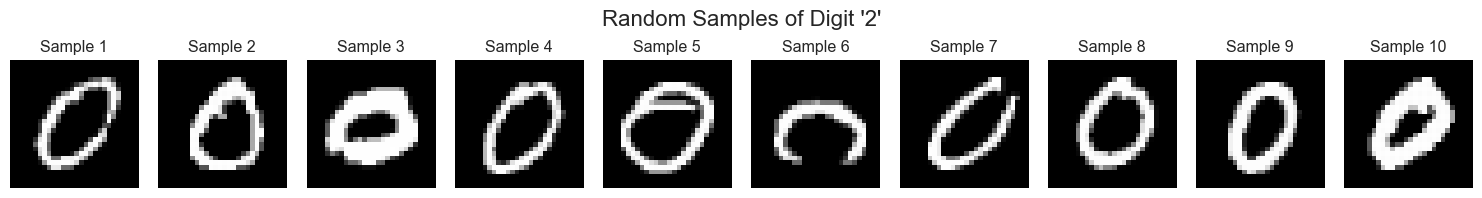

In [213]:
display_number(user_defined_num = 0)

### NUM. Draw Scree Plot of 20 PCs Explained Variance

In [ ]:
run_mnist_spatial_analysis("mnist.csv", n_components=20)

### Predict: Linear Regression Plus PCA to Restore Image based on Left

In [ ]:
run_hd_reconstruction_demo(X_global,y_global)